<a href="https://colab.research.google.com/github/Saumya7verma/Machine-Learning/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### **Import Libraries**

In [ ]:
# Data Handling Libraries
import pandas as pd  # Used for working with datasets
import numpy as np   # Used for numerical operations and arrays.

# Data Visualization Libraries
import matplotlib.pyplot as plt   # Used to create graphs and charts.
import seaborn as sns   # Used for attractive statistical visualizations.

# Machine Learning Utilities
from sklearn.model_selection import train_test_split   # Imports a function to split data into: Training data,Testing data

# Machine Learning Algorithms
from sklearn.linear_model import LinearRegression      # Predicts values using a straight-line relationship.
from sklearn.ensemble import RandomForestRegressor     # A powerful ML model that uses many decision trees together.

# Model Evaluation Metrics
from sklearn.metrics import mean_absolute_error, r2_score    # Used to check how good the model is.

### **Load Dataset**

In [ ]:
df = pd.read_csv('train.csv')  # Loads CSV file into a Pandas DataFrame.

In [ ]:
df.head()  # Shows the first 5 rows of the dataset.

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### **Understand Dataset**

In [ ]:
df.shape   # Tells the size of the dataset (rows, columns)

(1460, 81)

In [ ]:
df.columns   # See column names

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

### **Select Important Features**

In [ ]:
# Create features
features = [
    'LotArea',
    'OverallQual',
    'OverallCond',
    'YearBuilt',
    'TotalBsmtSF',
    'GrLivArea',
    'FullBath',
    'BedroomAbvGr',
    'GarageCars'
]

In [ ]:
# Target column
target = 'SalePrice'

### **Prepare Data**

In [ ]:
# Selects the feature columns from the dataset.
X = df[features]

# Selects the target/output column.
y = df[target]

In [ ]:
# Fills missing values in the dataset using the mean (average) of each column.
X = X.fillna(X.mean())

### **Data Visualization**

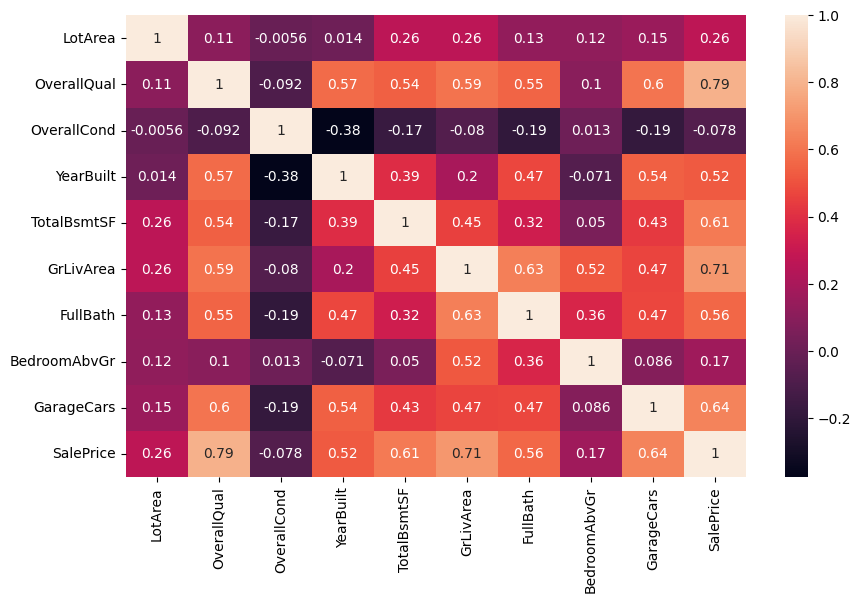

In [ ]:
'''
It creates a correlation heatmap to show relationships between features and the target variable.
It helps you understand:
Which features strongly affect house prices
Which columns are related to each other

'''

plt.figure(figsize=(10,6))

sns.heatmap(
    df[features + [target]].corr(),
    annot=True
)

plt.show()

### **Split Data**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,  # Training feature data used to teach the model
    y,  # Testing feature data used to evaluate the model
    test_size=0.2,   # 20% data → testing. 80% data → training
    random_state=42  # It ensures same split every time you run the code
)

### **Train Linear Regression Model**

'''
  Linear Regression predicts values using a linear relationship between:

Inputs (X)

Output (y)

Example:

Bigger house → higher price

The model tries to learn an equation like:

y=b0
 +b
1
 x
1
 +b
2
 x
2
 +⋯+b
n
 x
n
​

Where:

y = predicted house price

x₁, x₂... = features

b values = learned weights '''

In [ ]:
lr_model = LinearRegression() # Creates a Linear Regression model


lr_model.fit(X_train, y_train) #Trains the model using training data

LinearRegression()

In [ ]:
# Train Linear Regression model to predict house prices for the test data.
lr_predictions = lr_model.predict(X_test)

### **Evaluate Model**

MAE

In [ ]:
'''
MAE tells :
“On average, how far are the predictions from the real values?”

'''
# Calculate the Mean Absolute Error (MAE) of the model
mae = mean_absolute_error(y_test, lr_predictions)

print("MAE:", mae)

MAE: 23369.597581054506


R² Score

In [ ]:
''' R² Score tells you:
“How well does the model explain the variation in house prices?”
It measures how well predictions fit the real data.
'''
r2 = r2_score(y_test, lr_predictions)

print("R2 Score:", r2)

R2 Score: 0.8114463186856123


### **Train Random Forest Model**

In [ ]:
'''
  Random Forest is an ensemble learning algorithm.
  It combines:
  many Decision Trees
  and averages their predictions
  to improve accuracy.
'''
rf_model = RandomForestRegressor(
    n_estimators=100,   #Use 100 decision trees
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Make Predictions
rf_predictions = rf_model.predict(X_test)

### **Evaluate Random Forest**

In [ ]:
# Calculate average prediction error MAE
# Smaller MAE = better model.
rf_mae = mean_absolute_error(y_test, rf_predictions)

# Calculates how well the model explains variation in house prices
# Higher R² = better model.
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest MAE:", rf_mae)
print("Random Forest R2:", rf_r2)

Random Forest MAE: 17721.364103065884
Random Forest R2: 0.8990632712119048


“The Random Forest Regression model outperformed Linear Regression with a lower Mean Absolute Error (17,721) and a higher R² score (0.899), indicating better predictive accuracy for house price estimation.”

### **Feature Importance**

In [ ]:
'''
finds and displays the importance of each feature in your Random Forest model.
Higher importance = greater influence on house price.
'''
importance = rf_model.feature_importances_    # calculates how important each feature is

# creates a table with: feature names, their importance scores
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

# sorts features from: highest importance to lowest importance
feature_importance.sort_values(
    by='Importance',
    ascending=False,
    inplace=True
)

print(feature_importance)


        Feature  Importance
1   OverallQual    0.578424
5     GrLivArea    0.176459
4   TotalBsmtSF    0.090486
3     YearBuilt    0.047808
0       LotArea    0.046575
8    GarageCars    0.026960
6      FullBath    0.011968
2   OverallCond    0.011203
7  BedroomAbvGr    0.010118


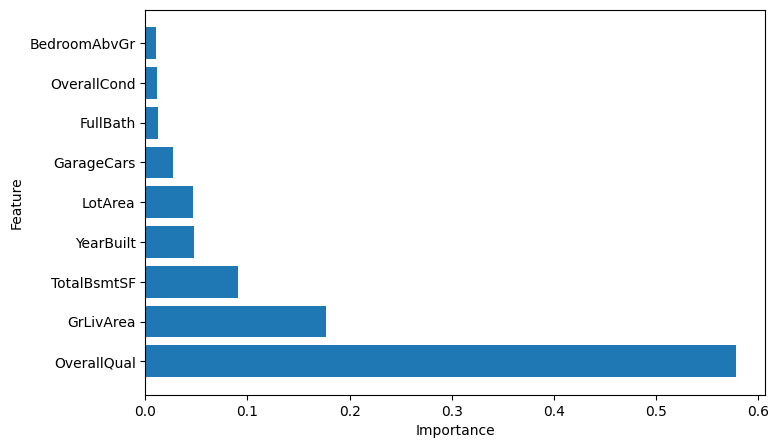

In [ ]:
# Create Figure
plt.figure(figsize=(8,5))

# Create Horizontal Bar Chart
plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### **Predict House Price**

In [ ]:
sample_house = pd.DataFrame([{
    'LotArea': 8450,
    'OverallQual': 7,
    'OverallCond': 5,
    'YearBuilt': 2003,
    'TotalBsmtSF': 856,
    'GrLivArea': 1710,
    'FullBath': 2,
    'BedroomAbvGr': 3,
    'GarageCars': 2
}])

prediction = rf_model.predict(sample_house)

print("Predicted Price:", prediction[0])

Predicted Price: 201701.0
